In [18]:
import sys
sys.path.insert(0, '/home/ubuntu/prem')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import warnings
import gc  # For memory management

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

## 1. Load Oulu Near-Miss Data

## 1.1. Position Extraction Function

In [19]:
def extract_positions_for_day(date_str, detections_df, data_dir="/home/ubuntu/data/uploads/oulu_data/objects/clean/objects/clean"):
    """
    Extract position information for detections on a specific day.
    Uses vectorized merge operations for fast matching.
    
    Args:
        date_str: Date string in format 'YYYY-MM-DD'
        detections_df: DataFrame with detection data (must have timestamp, id1, id2)
        data_dir: Path to parquet data directory
    
    Returns:
        DataFrame with added position columns (pos_x1, pos_y1, pos_x2, pos_y2)
    """
    from datetime import datetime
    import glob
    
    print(f"\n{'='*60}")
    print(f"Processing {date_str}")
    print(f"{'='*60}")
    
    # Filter detections for this day
    detections_df['timestamp_dt'] = pd.to_datetime(detections_df['timestamp'])
    detections_df['date'] = detections_df['timestamp_dt'].dt.date
    day_detections = detections_df[detections_df['date'] == pd.to_datetime(date_str).date()].copy()
    
    if len(day_detections) == 0:
        print(f"⚠ No detections found for {date_str}")
        return pd.DataFrame()
    
    print(f"Found {len(day_detections)} detections to enrich")
    
    # Get all hourly folders for this day
    hourly_folders = sorted(glob.glob(f"{data_dir}/{date_str}-*"))
    print(f"Found {len(hourly_folders)} hourly folders")
    
    if len(hourly_folders) == 0:
        print(f"⚠ No parquet data found for {date_str}")
        return day_detections
    
    # Collect all parquet data for this day (load hour by hour)
    all_parquet_data = []
    
    for hour_folder in hourly_folders:
        parquet_files = sorted(glob.glob(f"{hour_folder}/*.parquet"))
        
        for parquet_file in parquet_files:
            # Load parquet file with only needed columns
            df_parquet = pd.read_parquet(parquet_file, columns=['timestamp', 'id', 'pos_x', 'pos_y'])
            df_parquet['timestamp'] = pd.to_datetime(df_parquet['timestamp'])
            all_parquet_data.append(df_parquet)
            
            # Clear memory
            del df_parquet
            gc.collect()
        
        print(f"  Loaded hour {hour_folder.split('/')[-1]}", end='\r')
    
    # Combine all parquet data for this day
    print(f"\n  Combining parquet data...")
    df_positions = pd.concat(all_parquet_data, ignore_index=True)
    del all_parquet_data
    gc.collect()
    
    print(f"  Total position records: {len(df_positions):,}")
    
    # Merge id1 positions (vectorized operation - FAST!)
    print(f"  Matching id1 positions...")
    day_detections = day_detections.merge(
        df_positions[['timestamp', 'id', 'pos_x', 'pos_y']],
        left_on=['timestamp_dt', 'id1'],
        right_on=['timestamp', 'id'],
        how='left',
        suffixes=('', '_tmp')
    )
    day_detections.rename(columns={'pos_x': 'pos_x1', 'pos_y': 'pos_y1'}, inplace=True)
    day_detections.drop(['id', 'timestamp_tmp'], axis=1, inplace=True, errors='ignore')
    
    # Merge id2 positions (vectorized operation - FAST!)
    print(f"  Matching id2 positions...")
    day_detections = day_detections.merge(
        df_positions[['timestamp', 'id', 'pos_x', 'pos_y']],
        left_on=['timestamp_dt', 'id2'],
        right_on=['timestamp', 'id'],
        how='left',
        suffixes=('', '_tmp')
    )
    day_detections.rename(columns={'pos_x': 'pos_x2', 'pos_y': 'pos_y2'}, inplace=True)
    day_detections.drop(['id', 'timestamp_tmp'], axis=1, inplace=True, errors='ignore')
    
    # Clear parquet data from memory
    del df_positions
    gc.collect()
    
    # Count matches
    matched_count = day_detections[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1).sum()
    print(f"✓ Matched {matched_count}/{len(day_detections)} detections ({matched_count/len(day_detections)*100:.1f}%)")
    
    # Drop temporary columns
    day_detections = day_detections.drop(['timestamp_dt', 'date'], axis=1, errors='ignore')
    
    return day_detections

In [20]:
# Process all available days for Oulu
results_base = Path("/home/ubuntu/prem/results/oulu")
lanes_dir = results_base / "lanes"
crosswalks_dir = results_base / "crosswalks"
data_dir = "/home/ubuntu/data/uploads/oulu_data/objects/clean/objects/clean"

# Get all available dates from both directories
all_dates = set()
if lanes_dir.exists():
    all_dates.update([d.name for d in lanes_dir.iterdir() if d.is_dir()])
if crosswalks_dir.exists():
    all_dates.update([d.name for d in crosswalks_dir.iterdir() if d.is_dir()])

all_dates = sorted(list(all_dates))

if len(all_dates) == 0:
    print("ERROR: No data found in lanes or crosswalks directories!")
    print(f"Checked: {lanes_dir} and {crosswalks_dir}")
else:
    print(f"Found {len(all_dates)} days of data for Oulu")
    print(f"Date range: {all_dates[0]} to {all_dates[-1]}\n")

# Separate storage for lanes and crosswalks (important for 3 heatmaps!)
lanes_detections = []
crosswalks_detections = []
daily_stats = []

print("Starting position extraction...")
print("Processing one day at a time for memory efficiency.\n")

for date_str in all_dates:
    lanes_csv = lanes_dir / date_str / f"mdrac_{date_str}.csv"
    crosswalks_csv = crosswalks_dir / date_str / f"mdrac_{date_str}.csv"
    
    lanes_count = 0
    crosswalks_count = 0
    
    # Process LANES
    if lanes_csv.exists():
        try:
            df_lanes = pd.read_csv(lanes_csv)
            print(f"\n📍 {date_str} - LANES: {len(df_lanes)} detections")
            
            df_lanes_enriched = extract_positions_for_day(date_str, df_lanes, data_dir)
            
            if len(df_lanes_enriched) > 0:
                df_lanes_enriched['date'] = date_str
                df_lanes_enriched['source'] = 'lanes'
                lanes_detections.append(df_lanes_enriched)
                # Check if position columns exist before filtering
                if all(col in df_lanes_enriched.columns for col in ['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']):
                    lanes_count = df_lanes_enriched[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1).sum()
            
            del df_lanes
            if len(df_lanes_enriched) > 0:
                del df_lanes_enriched
            gc.collect()
        except Exception as e:
            print(f"⚠ Error processing lanes for {date_str}: {e}")
    
    # Process CROSSWALKS
    if crosswalks_csv.exists():
        try:
            df_crosswalks = pd.read_csv(crosswalks_csv)
            print(f"\n🚶 {date_str} - CROSSWALKS: {len(df_crosswalks)} detections")
            
            df_crosswalks_enriched = extract_positions_for_day(date_str, df_crosswalks, data_dir)
            
            if len(df_crosswalks_enriched) > 0:
                df_crosswalks_enriched['date'] = date_str
                df_crosswalks_enriched['source'] = 'crosswalks'
                crosswalks_detections.append(df_crosswalks_enriched)
                # Check if position columns exist before filtering
                if all(col in df_crosswalks_enriched.columns for col in ['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']):
                    crosswalks_count = df_crosswalks_enriched[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1).sum()
            
            del df_crosswalks
            if len(df_crosswalks_enriched) > 0:
                del df_crosswalks_enriched
            gc.collect()
        except Exception as e:
            print(f"⚠ Error processing crosswalks for {date_str}: {e}")
    
    daily_stats.append({
        'Date': date_str,
        'Lanes': lanes_count,
        'Crosswalks': crosswalks_count,
        'Total': lanes_count + crosswalks_count
    })

# Create separate DataFrames for lanes and crosswalks
if lanes_detections:
    df_lanes_all = pd.concat(lanes_detections, ignore_index=True)
    # Only filter if position columns exist
    if all(col in df_lanes_all.columns for col in ['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']):
        df_lanes_all = df_lanes_all[df_lanes_all[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1)].copy()
        print(f"\n✓ LANES: {len(df_lanes_all):,} enriched conflicts")
    else:
        print("\n⚠ LANES: Position columns missing - no enrichment performed")
else:
    df_lanes_all = pd.DataFrame()
    print("\n⚠ No lanes data")

if crosswalks_detections:
    df_crosswalks_all = pd.concat(crosswalks_detections, ignore_index=True)
    # Only filter if position columns exist
    if all(col in df_crosswalks_all.columns for col in ['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']):
        df_crosswalks_all = df_crosswalks_all[df_crosswalks_all[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1)].copy()
        print(f"✓ CROSSWALKS: {len(df_crosswalks_all):,} enriched conflicts")
    else:
        print("⚠ CROSSWALKS: Position columns missing - no enrichment performed")
else:
    df_crosswalks_all = pd.DataFrame()
    print("⚠ No crosswalks data")

# Combined dataset
all_detections = lanes_detections + crosswalks_detections
if all_detections:
    df_all = pd.concat(all_detections, ignore_index=True)
    # Only filter if position columns exist
    if all(col in df_all.columns for col in ['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']):
        df_all = df_all[df_all[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1)].copy()
        print(f"✓ COMBINED: {len(df_all):,} enriched conflicts")
    else:
        print("⚠ COMBINED: Position columns missing - no enrichment performed")
else:
    df_all = pd.DataFrame()
    print("⚠ No combined data")

# Create stats table
stats_df = pd.DataFrame(daily_stats)

print(f"\n{'='*60}")
print(f"✓ DATA LOADING COMPLETE")
print(f"{'='*60}")
print(f"Lanes conflicts: {len(df_lanes_all) if len(df_lanes_all) > 0 else 0:,}")
print(f"Crosswalks conflicts: {len(df_crosswalks_all) if len(df_crosswalks_all) > 0 else 0:,}")
print(f"Total conflicts: {len(df_all) if len(df_all) > 0 else 0:,}")
print(f"{'='*60}\n")

Found 31 days of data for Oulu
Date range: 2025-07-10 to 2025-09-11

Starting position extraction...
Processing one day at a time for memory efficiency.


📍 2025-07-10 - LANES: 1 detections

Processing 2025-07-10
Found 1 detections to enrich
Found 13 hourly folders
  Loaded hour 2025-07-10-23
  Combining parquet data...
  Total position records: 1,146,921
  Matching id1 positions...
  Matching id2 positions...
✓ Matched 1/1 detections (100.0%)

🚶 2025-07-10 - CROSSWALKS: 7 detections

Processing 2025-07-10
Found 7 detections to enrich
Found 13 hourly folders
  Loaded hour 2025-07-10-23
  Combining parquet data...
  Total position records: 1,146,921
  Matching id1 positions...
  Matching id2 positions...
✓ Matched 7/7 detections (100.0%)

🚶 2025-07-11 - CROSSWALKS: 2 detections

Processing 2025-07-11
Found 2 detections to enrich
Found 6 hourly folders
  Loaded hour 2025-07-11-12
  Combining parquet data...
  Total position records: 741,959
  Matching id1 positions...
  Matching id2 posi

### Memory-Efficient Approach

The position extraction uses the following strategy to handle large parquet files:

1. **Process one day at a time** - Each day is loaded, processed, and cleared from memory before moving to the next
2. **Within each day, process one 15-minute parquet file at a time** - Immediately clear after matching
3. **Timestamp + Object ID matching** - Find positions for id1 and id2 at the exact detection timestamp
4. **Garbage collection** - Explicitly free memory after each chunk using `gc.collect()`

This approach can handle 14 days of data (~6GB total) with minimal memory footprint (only ~100-200MB at a time).

## 2. Oulu Statistics

In [21]:
print("="*60)
print("OULU NEAR-MISS STATISTICS")
print("="*60)
print(stats_df.to_string(index=False))
print("="*60)
print(f"Total Lanes Conflicts: {stats_df['Lanes'].sum():,}")
print(f"Total Crosswalks Conflicts: {stats_df['Crosswalks'].sum():,}")
print(f"Grand Total: {stats_df['Total'].sum():,}")
print("="*60)

OULU NEAR-MISS STATISTICS
      Date  Lanes  Crosswalks  Total
2025-07-10      1           7      8
2025-07-11      0           2      2
2025-08-01      0           2      2
2025-08-02      0           4      4
2025-08-03      0           1      1
2025-08-05      4          13     17
2025-08-08      0           3      3
2025-08-10      0           3      3
2025-08-11      2           7      9
2025-08-14      1          12     13
2025-08-22      0           0      0
2025-08-23      0           9      9
2025-08-24      0           1      1
2025-08-25      1          18     19
2025-08-26      2          14     16
2025-08-27      1          14     15
2025-08-28      2          26     28
2025-08-29      3          31     34
2025-08-30      0           8      8
2025-08-31      0           4      4
2025-09-01      0          15     15
2025-09-02      3          15     18
2025-09-03      3          32     35
2025-09-04      4          34     38
2025-09-05      2          32     34
2025-09-06  

## 3. Load Oulu Zone Geometry

In [22]:
from shapely.geometry import Polygon
from shapely import wkt
import geopandas as gpd

# Define the Oulu zone polygon
zone_wkt = ("POLYGON ((69.982 -16.398, 69.982 10.125, 18.728 9.409, 13.351 13.71, "
            "12.993 57.796, -0.269 57.975, 0.627 17.473, -2.599 14.247, -48.656 15.143, "
            "-48.656 -15.681, 69.982 -16.398))")

# Create GeoDataFrame with the zone
zone_geom = wkt.loads(zone_wkt)
gdf_zones = gpd.GeoDataFrame(
    [{'name': 'Oulu Analysis Zone', 'geometry': zone_geom}],
    geometry='geometry'
)

print(f"✓ Loaded Oulu analysis zone")
print(f"✓ Zone area: {zone_geom.area:.2f} m²")
print(f"✓ Zone bounds: {zone_geom.bounds}")

✓ Loaded Oulu analysis zone
✓ Zone area: 3940.30 m²
✓ Zone bounds: (-48.656, -16.398, 69.982, 57.975)


## 4. Heatmap Generation Function

In [23]:
def create_risk_heatmap(conflicts_df, gdf_zones, influence_radius=3.0, grid_resolution=0.5):
    """
    Create risk heatmap using influence circles.
    
    Args:
        conflicts_df: DataFrame with conflict locations (pos_x1, pos_y1)
        gdf_zones: GeoDataFrame with zone geometries
        influence_radius: Radius of influence circle in meters
        grid_resolution: Grid cell size in meters
    """
    # Get conflict locations
    if 'pos_x1' in conflicts_df.columns and 'pos_y1' in conflicts_df.columns:
        conflict_points = conflicts_df[['pos_x1', 'pos_y1']].dropna()
    else:
        print("⚠ No position columns found, checking alternatives...")
        print(f"Available columns: {conflicts_df.columns.tolist()}")
        return None
    
    print(f"Processing {len(conflict_points):,} conflict locations...")
    
    # Determine grid bounds from zones
    bounds = gdf_zones.total_bounds  # [minx, miny, maxx, maxy]
    x_min, y_min, x_max, y_max = bounds
    
    # Add padding
    padding = 10
    x_min -= padding
    y_min -= padding
    x_max += padding
    y_max += padding
    
    print(f"Grid bounds: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
    
    # Create grid
    x_range = np.arange(x_min, x_max, grid_resolution)
    y_range = np.arange(y_min, y_max, grid_resolution)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Initialize strength grid
    strength = np.zeros_like(X)
    
    # Add influence from each conflict
    print(f"Computing influence circles (radius={influence_radius}m)...")
    for idx, row in conflict_points.iterrows():
        # Get x, y coordinates from row
        x, y = row['pos_x1'], row['pos_y1']
        
        # Compute distance from this conflict to all grid points
        dist = np.sqrt((X - x)**2 + (Y - y)**2)
        
        # Add influence (1 within radius, 0 outside)
        # Using Gaussian influence for smoother heatmap
        influence = np.exp(-0.5 * (dist / influence_radius)**2)
        strength += influence
    
    # Normalize strength to [0, 1]
    if strength.max() > 0:
        strength_normalized = strength / strength.max()
    else:
        strength_normalized = strength
    
    print(f"✓ Heatmap created: Max strength = {strength.max():.2f}")
    
    return X, Y, strength_normalized, bounds

In [24]:
# Generate heatmap for LANES
if len(df_lanes_all) > 0:
    print("\n" + "="*60)
    print("GENERATING LANES HEATMAP")
    print("="*60)
    heatmap_lanes = create_risk_heatmap(df_lanes_all, gdf_zones, influence_radius=3.0, grid_resolution=0.5)
else:
    print("\n⚠ No lanes data for heatmap")
    heatmap_lanes = None

# Generate heatmap for CROSSWALKS
if len(df_crosswalks_all) > 0:
    print("\n" + "="*60)
    print("GENERATING CROSSWALKS HEATMAP")
    print("="*60)
    heatmap_crosswalks = create_risk_heatmap(df_crosswalks_all, gdf_zones, influence_radius=3.0, grid_resolution=0.5)
else:
    print("\n⚠ No crosswalks data for heatmap")
    heatmap_crosswalks = None

# Generate heatmap for COMBINED
if len(df_all) > 0:
    print("\n" + "="*60)
    print("GENERATING COMBINED HEATMAP")
    print("="*60)
    heatmap_combined = create_risk_heatmap(df_all, gdf_zones, influence_radius=3.0, grid_resolution=0.5)
else:
    print("\n⚠ No combined data for heatmap")
    heatmap_combined = None


GENERATING LANES HEATMAP
Processing 33 conflict locations...
Grid bounds: X[-58.7, 80.0], Y[-26.4, 68.0]
Computing influence circles (radius=3.0m)...
✓ Heatmap created: Max strength = 11.58

GENERATING CROSSWALKS HEATMAP
Processing 440 conflict locations...
Grid bounds: X[-58.7, 80.0], Y[-26.4, 68.0]
Computing influence circles (radius=3.0m)...
✓ Heatmap created: Max strength = 274.89

GENERATING COMBINED HEATMAP
Processing 473 conflict locations...
Grid bounds: X[-58.7, 80.0], Y[-26.4, 68.0]
Computing influence circles (radius=3.0m)...
✓ Heatmap created: Max strength = 274.89


## 5. Visualize LANES Heatmap

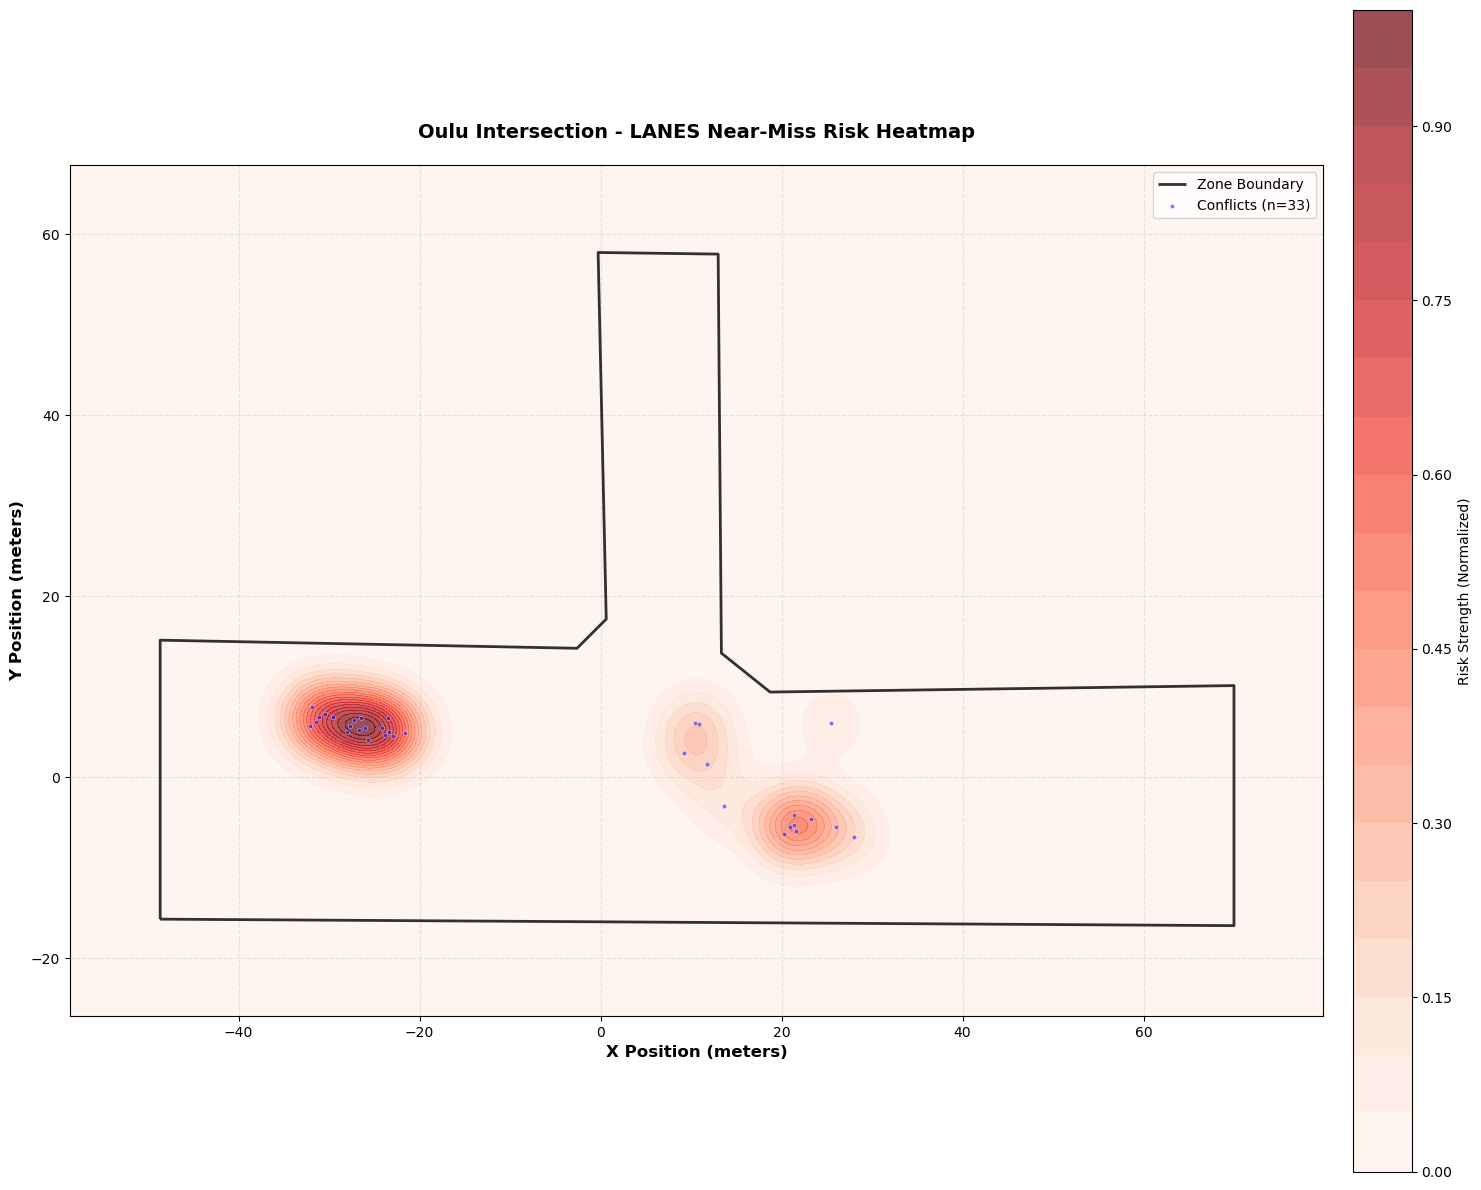


✓ LANES heatmap generated with 33 conflicts


In [25]:
if heatmap_lanes is not None:
    X, Y, strength, bounds = heatmap_lanes
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot heatmap
    heatmap = ax.contourf(X, Y, strength, levels=20, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    
    # Plot zone boundaries
    gdf_zones.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.8, label='Zone Boundary')
    
    # Plot conflict points
    if 'pos_x1' in df_lanes_all.columns:
        ax.scatter(df_lanes_all['pos_x1'], df_lanes_all['pos_y1'], 
                   c='blue', s=10, alpha=0.5, edgecolors='white', linewidths=0.5,
                   label=f'Conflicts (n={len(df_lanes_all):,})', zorder=5)
    
    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax, label='Risk Strength (Normalized)', pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    
    # Styling
    ax.set_xlabel('X Position (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (meters)', fontsize=12, fontweight='bold')
    ax.set_title('Oulu Intersection - LANES Near-Miss Risk Heatmap', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ LANES heatmap generated with {len(df_lanes_all):,} conflicts")
else:
    print("Cannot create LANES heatmap - no data available.")

## 6. Visualize CROSSWALKS Heatmap

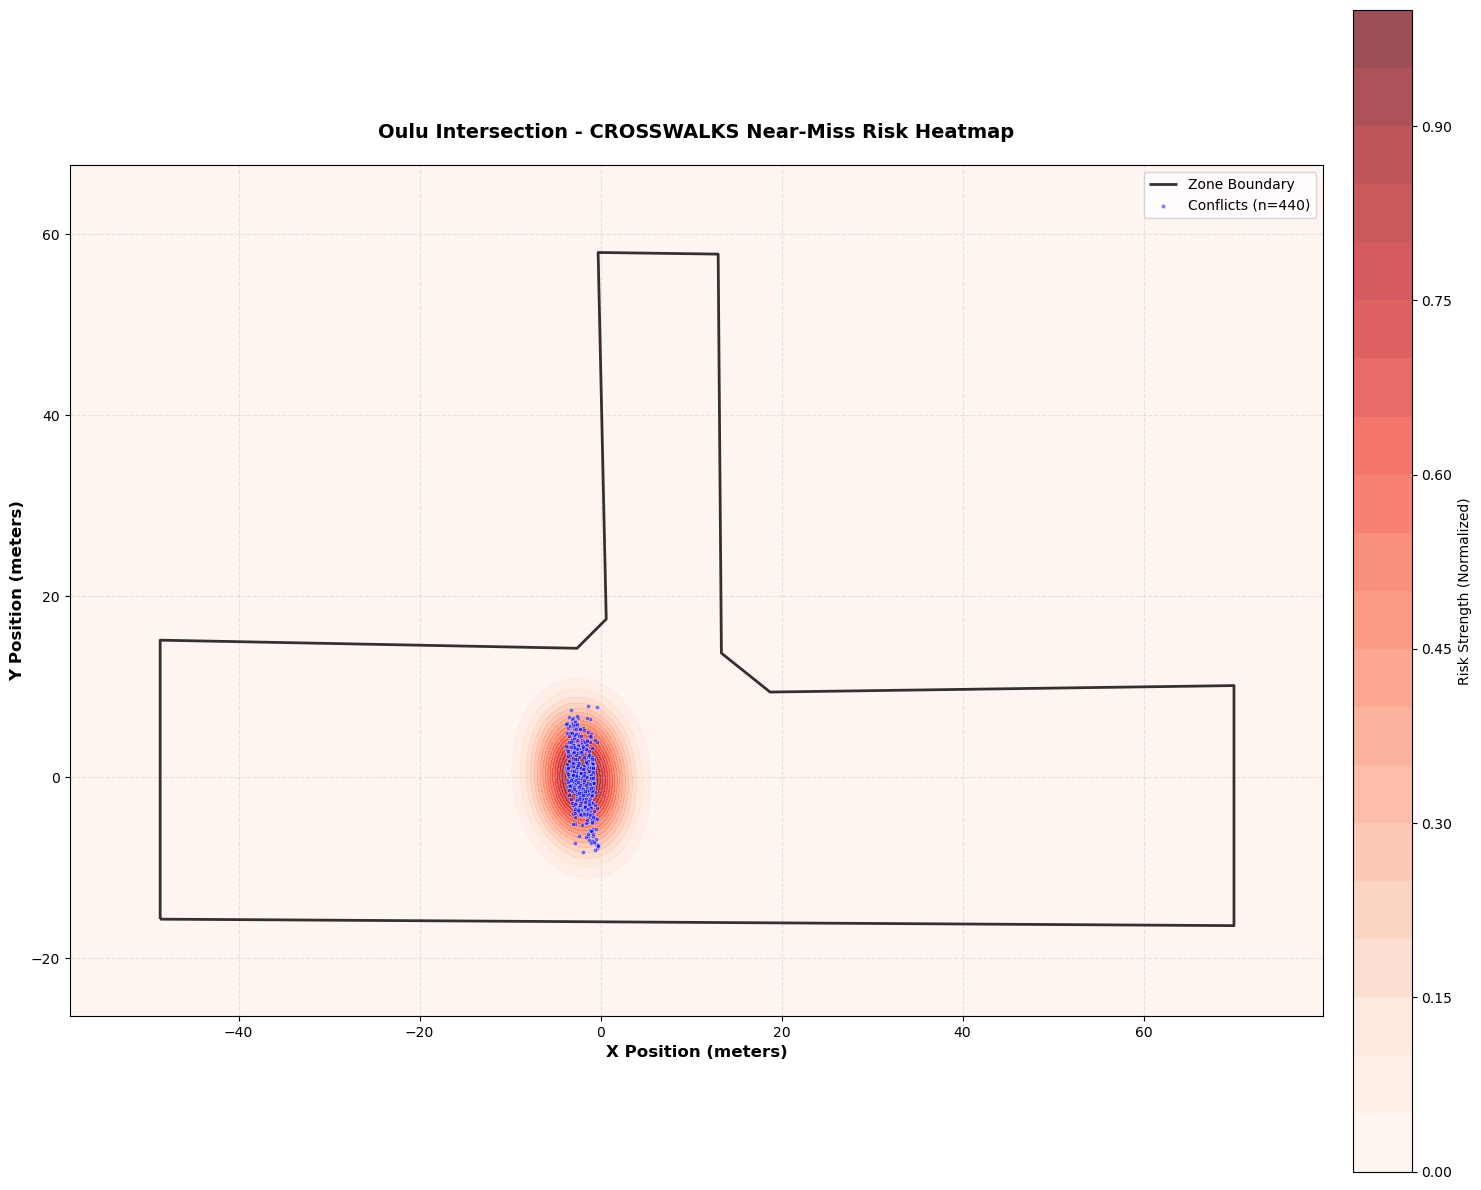


✓ CROSSWALKS heatmap generated with 440 conflicts


In [26]:
if heatmap_crosswalks is not None:
    X, Y, strength, bounds = heatmap_crosswalks
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot heatmap
    heatmap = ax.contourf(X, Y, strength, levels=20, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    
    # Plot zone boundaries
    gdf_zones.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.8, label='Zone Boundary')
    
    # Plot conflict points
    if 'pos_x1' in df_crosswalks_all.columns:
        ax.scatter(df_crosswalks_all['pos_x1'], df_crosswalks_all['pos_y1'], 
                   c='blue', s=10, alpha=0.5, edgecolors='white', linewidths=0.5,
                   label=f'Conflicts (n={len(df_crosswalks_all):,})', zorder=5)
    
    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax, label='Risk Strength (Normalized)', pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    
    # Styling
    ax.set_xlabel('X Position (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (meters)', fontsize=12, fontweight='bold')
    ax.set_title('Oulu Intersection - CROSSWALKS Near-Miss Risk Heatmap', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ CROSSWALKS heatmap generated with {len(df_crosswalks_all):,} conflicts")
else:
    print("Cannot create CROSSWALKS heatmap - no data available.")

## 7. Visualize COMBINED Heatmap

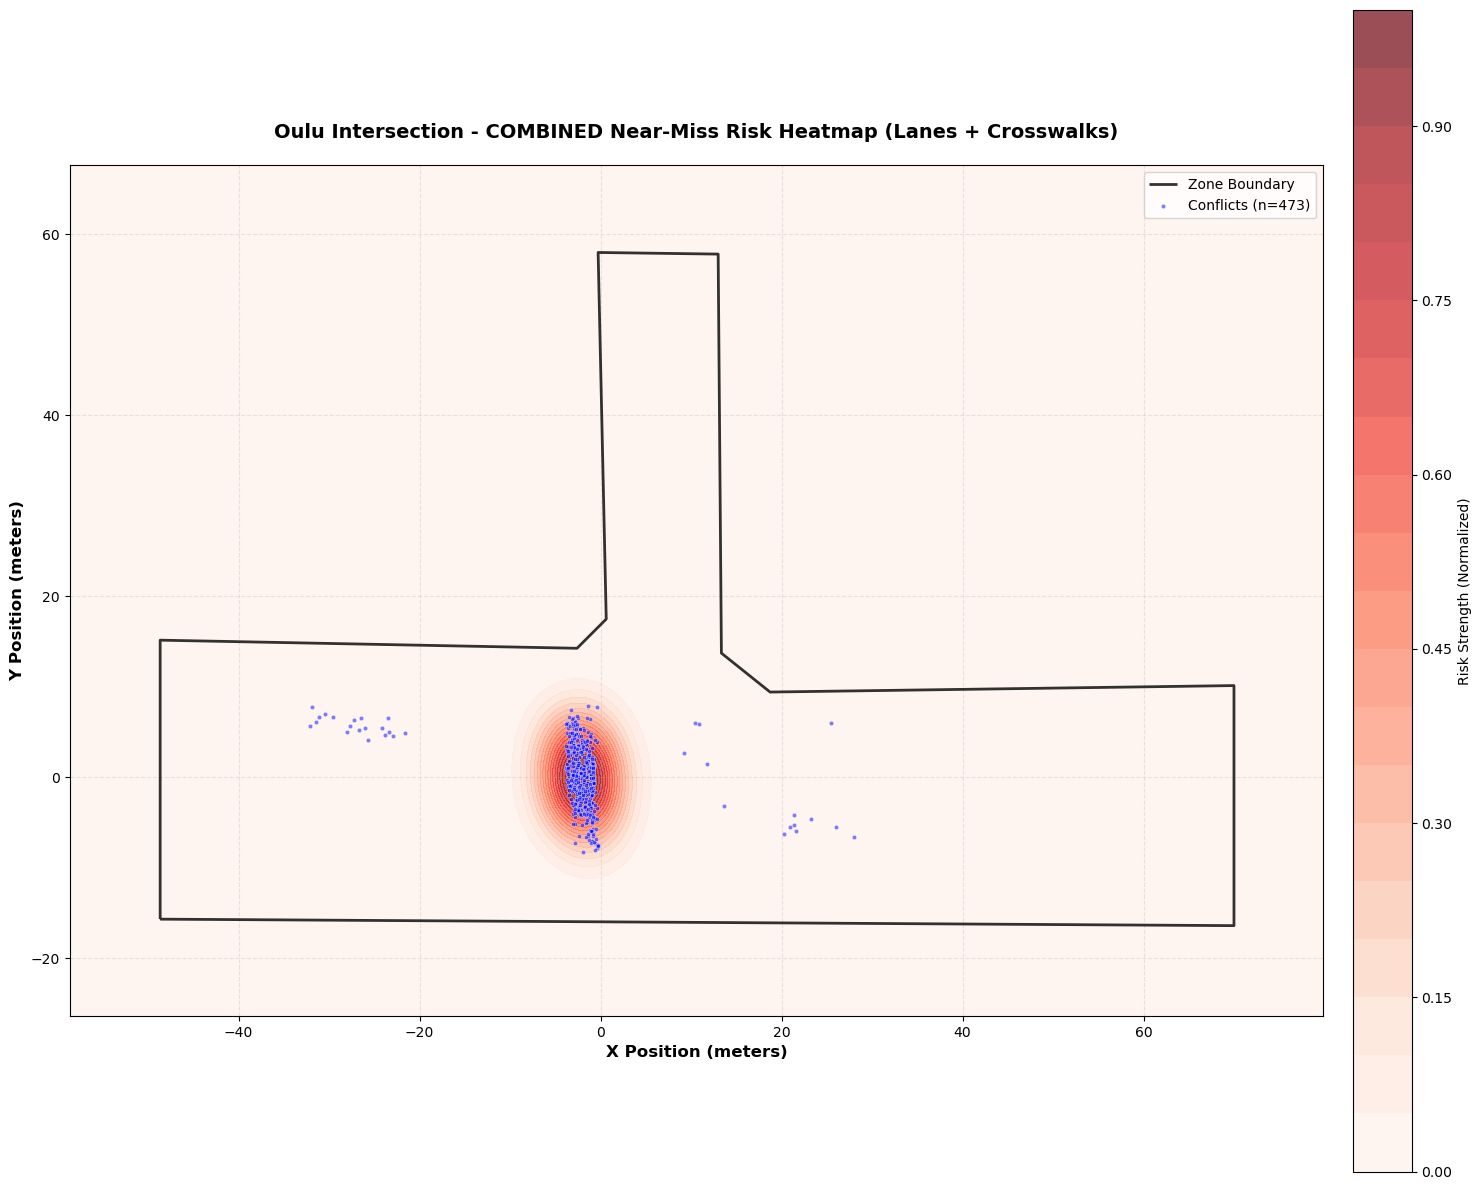


✓ COMBINED heatmap generated with 473 conflicts
  - Lanes: 33
  - Crosswalks: 440


In [27]:
if heatmap_combined is not None:
    X, Y, strength, bounds = heatmap_combined
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot heatmap
    heatmap = ax.contourf(X, Y, strength, levels=20, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    
    # Plot zone boundaries
    gdf_zones.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.8, label='Zone Boundary')
    
    # Plot conflict points
    if 'pos_x1' in df_all.columns:
        ax.scatter(df_all['pos_x1'], df_all['pos_y1'], 
                   c='blue', s=10, alpha=0.5, edgecolors='white', linewidths=0.5,
                   label=f'Conflicts (n={len(df_all):,})', zorder=5)
    
    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax, label='Risk Strength (Normalized)', pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    
    # Styling
    ax.set_xlabel('X Position (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (meters)', fontsize=12, fontweight='bold')
    ax.set_title('Oulu Intersection - COMBINED Near-Miss Risk Heatmap (Lanes + Crosswalks)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ COMBINED heatmap generated with {len(df_all):,} conflicts")
    print(f"  - Lanes: {len(df_lanes_all):,}")
    print(f"  - Crosswalks: {len(df_crosswalks_all):,}")
else:
    print("Cannot create COMBINED heatmap - no data available.")